# import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##  Load Dataset and Initial Inspection

Before making any changes, we load the data and get a first look at its shape, column types, and sample rows.

In [2]:
df = pd.read_excel("cleaned_dataset_Yazdan-Rezaei.xlsx")

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Unnamed: 0          58 non-null     int64         
 1   customer_id         58 non-null     int64         
 2   first_name          58 non-null     object        
 3   gender              58 non-null     object        
 4   age                 58 non-null     int64         
 5   city                58 non-null     object        
 6   province            58 non-null     object        
 7   signup_date         58 non-null     datetime64[ns]
 8   membership_tier     58 non-null     object        
 9   purchase_count      58 non-null     int64         
 10  avg_order_value     58 non-null     float64       
 11  total_spending      58 non-null     float64       
 12  last_purchase_days  58 non-null     int64         
 13  payment_method      58 non-null     object        
 

,Unnamed: 0,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [3]:
total_customers = df["customer_id"].nunique()
total_purchases = df["purchase_count"].sum()
total_revenue = df["total_spending"].sum()
avg_spending_per_customer = df["total_spending"].mean()
avg_order_value = df["avg_order_value"].mean()
return_rate = df["returned_items"].sum() / df["purchase_count"].sum() * 100
avg_satisfaction = df["satisfaction_score"].mean()

summary = pd.Series({
    "Total Customers": total_customers,
    "Total Purchases": total_purchases,
    "Total Revenue": round(total_revenue, 2),
    "Avg Spending per Customer": round(avg_spending_per_customer, 2),
    "Avg Order Value": round(avg_order_value, 2),
    "Return Rate (%)": round(return_rate, 2),
    "Avg Satisfaction (out of 5)": round(avg_satisfaction, 2),
})
summary

Total Customers                    58.00
Total Purchases                   993.00
Total Revenue                  218631.43
Avg Spending per Customer        3769.51
Avg Order Value                   216.63
Return Rate (%)                    24.87
Avg Satisfaction (out of 5)         2.97
dtype: float64

**Result and interpretation:**

The store has **58 customers** in total, who made **993 purchases** and generated **218,631 currency units** of revenue. On average, each customer spent about **3,770 units**, and each order was worth about **217 units**.

Two numbers here are concerning:
- **Return rate of 24.87%** — roughly 1 in every 4 purchased items gets returned. This is high and could point to problems with product quality, product descriptions, or sizing/fit.
- **Average satisfaction of only 2.97 out of 5** — customer satisfaction is below the midpoint, not great.

Takeaway: the store is generating meaningful revenue, but the customer-experience signals (low satisfaction + high return rate) suggest that growth shouldn't come only from advertising — fixing the underlying customer experience issues should also be a priority.

## City Selection for Advertising

In [10]:
city_analysis = df.groupby("city").agg(
    customers=("customer_id", "nunique"),
    purchases=("purchase_count", "sum"),
    revenue=("total_spending", "sum"),
    avg_spending=("total_spending", "mean"),
    satisfaction=("satisfaction_score", "mean"),
)

return_rate_by_city = df.groupby("city").apply(
    lambda g: g["returned_items"].sum() / g["purchase_count"].sum() * 100,
    include_groups=False
)

city_analysis["return_rate_pct"] = return_rate_by_city
city_analysis = city_analysis.sort_values("revenue", ascending=False).round(2)
city_analysis

,customers,purchases,revenue,avg_spending,satisfaction,return_rate_pct
city,,,,,,
Mashhad,11,249,64118.44,5828.95,2.91,11.65
Tabriz,12,189,36192.49,3016.04,3.00,29.10
Karaj,7,112,26189.81,3741.40,2.86,30.36
Ahvaz,8,111,23384.78,2923.10,3.50,35.14
Shiraz,6,98,20715.92,3452.65,2.00,29.59
Isfahan,4,83,18980.60,4745.15,4.25,25.30
Rasht,5,82,15168.54,3033.71,2.60,26.83
Tehran,5,69,13880.85,2776.17,2.80,26.09


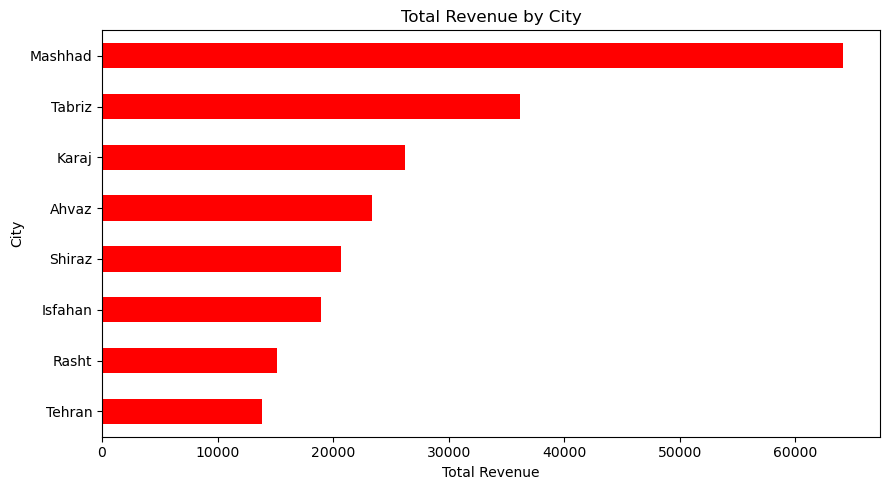

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

city_analysis["revenue"].sort_values().plot(kind="barh", ax=ax, color="red")
ax.set_xlabel("Total Revenue")
ax.set_ylabel("City")
ax.set_title("Total Revenue by City")
plt.tight_layout()

plt.show()

**Result and interpretation:**

in my idea **Mashhad** is the best choice for advertising:

| Metric | Mashhad | Average of other cities |
|---|---|---|
| Revenue | 64,118 (highest, almost 2x the next city) | ~22,000 |
| Avg spending per customer | 5,829 (highest) | ~3,300 |
| Return rate | only **11.7%** (far lower than the rest) | ~29% |
| Satisfaction | 2.91 (close to the overall average) | — |

**Why I chose it:** Mashhad has both the highest revenue and the lowest return rate — meaning its customers are both high-value and cause the fewest quality/satisfaction issues. This combination suggests advertising spend there is more likely to have a good return, since we'd be investing in a market that already has healthy purchasing behavior.



##  Selecting 10 Customers for a Loyalty Campaign


**Method:** We build a weighted composite score from 4 normalized variables (scaled 0–1):
- `total_spending` (weight 35%) — customer's financial value
- `purchase_count` (weight 25%) — engagement and loyalty
- `satisfaction_score` (weight 25%) — positive experience, higher chance of staying
- `last_purchase_days` inverted (weight 15%) — recency of activity (the more recent, the better)

In [8]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df["loyalty_score"] = (
    normalize(df["total_spending"]) * 0.35
    + normalize(df["purchase_count"]) * 0.25
    + normalize(df["satisfaction_score"]) * 0.25
    + normalize(-df["last_purchase_days"]) * 0.15
)

top10 = df.sort_values("loyalty_score", ascending=False).head(10).copy()
top10["Reason for Selection"] = "High spending & purchase frequency, strong satisfaction, recently active"

loyalty_table = top10[[
    "customer_id", "first_name", "city", "membership_tier",
    "purchase_count", "total_spending", "last_purchase_days",
    "satisfaction_score", "Reason for Selection"
]].rename(columns={
    "customer_id": "Customer ID",
    "first_name": "Customer Name",
    "city": "City",
    "membership_tier": "Membership Tier",
    "purchase_count": "Purchase Count",
    "total_spending": "Total Spending",
    "last_purchase_days": "Last Purchase Days",
    "satisfaction_score": "Satisfaction Score",
})
loyalty_table

,Customer ID,Customer Name,City,Membership Tier,Purchase Count,Total Spending,Last Purchase Days,Satisfaction Score,Reason for Selection
28,1030,Sina,Mashhad,VIP,26,25000.00,340,4,"High spending & purchase frequency, strong sat..."
54,1057,Maryam,Ahvaz,Bronze,31,13532.74,82,4,"High spending & purchase frequency, strong sat..."
56,1059,Ali,Isfahan,Gold,31,8898.55,224,5,"High spending & purchase frequency, strong sat..."
31,1033,Neda,Tabriz,VIP,24,5521.20,112,5,"High spending & purchase frequency, strong sat..."
41,1044,Mina,Shiraz,Gold,33,14354.34,165,2,"High spending & purchase frequency, strong sat..."
3,1004,Sina,Mashhad,Gold,23,6121.45,40,4,"High spending & purchase frequency, strong sat..."
13,1014,Reza,Tabriz,VIP,31,3353.89,97,4,"High spending & purchase frequency, strong sat..."
0,1001,Reza,Karaj,VIP,17,2066.01,16,5,"High spending & purchase frequency, strong sat..."
21,1023,Ali,Mashhad,Bronze,31,3851.44,170,4,"High spending & purchase frequency, strong sat..."
16,1017,Parsa,Ahvaz,VIP,30,3239.40,135,4,"High spending & purchase frequency, strong sat..."


**Result and interpretation:**

These 10 customers combine high spending, frequent purchases, good satisfaction, and recent activity — exactly the profile of a customer worth investing in to retain.

##  Identifying At-Risk (Churn) Customers

**Our definition of an "at-risk" customer:** a customer who previously had high purchase value (`total_spending` at or above the median across all customers) but hasn't purchased in a long time (`last_purchase_days > 180`, i.e. more than 6 months). We chose this definition deliberately because this group carries the highest risk of real revenue loss — they were valuable before, so losing them has a real opportunity cost (unlike a customer who was low-spending from the start).

**Condition used in Python:**
```python
(total_spending >= median) & (last_purchase_days > 180)
```

In [12]:
median_spending = df["total_spending"].median()

churn_risk = df[
    (df["total_spending"] >= median_spending)
    & (df["last_purchase_days"] > 180)
].sort_values("total_spending", ascending=False)

print(f"Median total spending: {median_spending:.2f}")
print(f"Number of at-risk customers identified: {len(churn_risk)}")

churn_risk[[
    "customer_id", "first_name", "city", "membership_tier",
    "total_spending", "last_purchase_days", "satisfaction_score"
]]

Median total spending: 2128.69
Number of at-risk customers identified: 18


,customer_id,first_name,city,membership_tier,total_spending,last_purchase_days,satisfaction_score
28,1030,Sina,Mashhad,VIP,25000.00,340,4
11,1012,Arash,Mashhad,Gold,11731.50,224,2
8,1009,Kimia,Karaj,Silver,11615.42,232,2
56,1059,Ali,Isfahan,Gold,8898.55,224,5
9,1010,Arash,Karaj,Silver,7241.47,276,1
47,1050,Reza,Mashhad,Bronze,6198.00,205,2
52,1055,Mina,Rasht,Bronze,6068.22,221,1
33,1035,Arash,Tabriz,Bronze,5918.21,365,3
50,1053,Sina,Tehran,Gold,5805.54,320,1
43,1046,Maryam,Tabriz,VIP,4923.45,229,4


**Result and interpretation:**

**18 customers** (out of 58, about 31% of the customer base) meet the "at-risk" criteria — a concerning number since it's nearly a third of all customers.

This group's average satisfaction (from the segmentation analysis below) is lower than the overall average, suggesting that dissatisfaction is likely a real driver of their inactivity, not just random disengagement.



##  Discount Impact Analysis


In [15]:
discount_comparison = df.groupby("discount_used").agg(
    customers=("customer_id", "nunique"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_spending=("total_spending", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
)

return_rate_by_discount = df.groupby("discount_used").apply(
    lambda g: g["returned_items"].sum() / g["purchase_count"].sum() * 100
    
)
discount_comparison["return_rate_pct"] = return_rate_by_discount
discount_comparison.round(2)

C:\Users\laptop4\AppData\Local\Temp\ipykernel_13048\2849172108.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return_rate_by_discount = df.groupby("discount_used").apply(


,customers,avg_purchase_count,avg_spending,avg_satisfaction,return_rate_pct
discount_used,,,,,
No,34,17.29,3736.74,2.76,24.66
Yes,24,16.88,3815.93,3.25,25.19


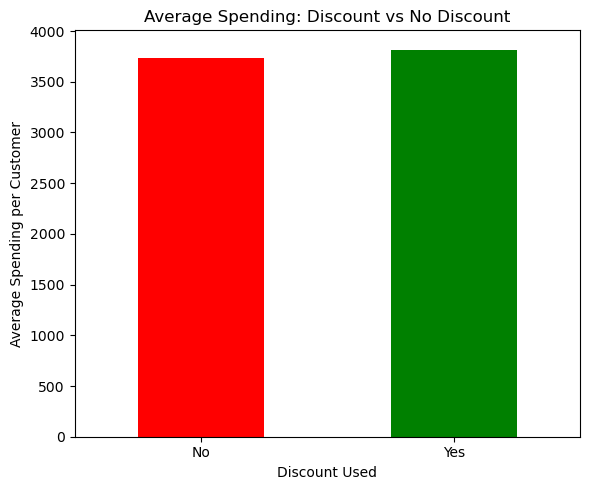

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
discount_comparison["avg_spending"].plot(kind="bar", ax=ax, color=["red", "green"])
ax.set_xlabel("Discount Used")
ax.set_ylabel("Average Spending per Customer")
ax.set_title("Average Spending: Discount vs No Discount")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()

plt.show()

##  Customer Segmentation



**Segmentation rules (using the median `total_spending` as the "high value" threshold):**

| Group | Rule |
|---|---|
| **Champions** | High spending + recent purchase (≤ 90 days) + high satisfaction (4 or 5) |
| **At Risk** | High spending + old purchase (> 180 days) — same definition as Question 4 |
| **Needs Attention** | Low spending + low satisfaction (1 or 2) |
| **Other Customers** | Everyone else (neither exceptional nor in crisis) |

In [19]:
median_spending = df["total_spending"].median()

def assign_segment(row):
    if (row["total_spending"] >= median_spending
            and row["last_purchase_days"] <= 90
            and row["satisfaction_score"] >= 4):
        return "Champions"
    elif (row["total_spending"] >= median_spending
          and row["last_purchase_days"] > 180):
        return "At Risk"
    elif (row["total_spending"] < median_spending
          and row["satisfaction_score"] <= 2):
        return "Needs Attention"
    else:
        return "Other Customers"

df["segment"] = df.apply(assign_segment, axis=1)

segment_summary = df.groupby("segment").agg(
    customers=("customer_id", "nunique"),
    avg_spending=("total_spending", "mean"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_last_purchase_days=("last_purchase_days", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
).round(2)
segment_summary

,customers,avg_spending,avg_purchase_count,avg_last_purchase_days,avg_satisfaction
segment,,,,,
At Risk,18,6655.89,22.22,265.72,2.72
Champions,2,9827.09,27.00,61.00,4.00
Needs Attention,13,1043.29,7.92,234.46,1.62
Other Customers,25,2624.33,17.44,153.32,3.76


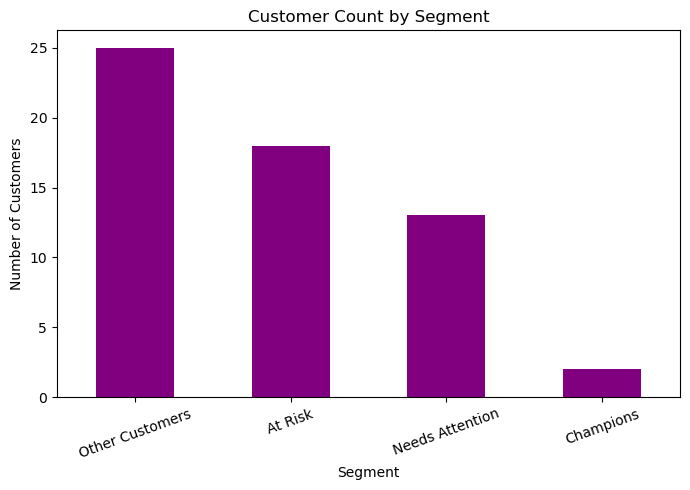

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
df["segment"].value_counts().plot(kind="bar", ax=ax, color="purple")
ax.set_xlabel("Segment")
ax.set_ylabel("Number of Customers")
ax.set_title("Customer Count by Segment")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
plt.tight_layout()

plt.show()

**Result and interpretation of each group:**

| Group | Count | Key trait | Suggested action |
|---|---|---|---|
| **Champions** | 2 | High spending, recent purchase, high satisfaction | Maintain the relationship via a VIP program; ask for feedback/referrals |
| **At Risk** | 18 | High spending historically, but inactive for a long time, below-average satisfaction | Win-back campaign (Question 4) with targeted discount + investigate dissatisfaction |
| **Needs Attention** | 13 | Both spending and satisfaction are low | Review this group's purchase experience; may need better support or different product recommendations |
| **Other Customers** | 25 | The core customer base, neither in crisis nor at the top | Maintain with standard loyalty programs; potential to grow into Champions |



##  Revenue Concentration (Pareto Analysis)

In [24]:
sorted_customers = df.sort_values("total_spending", ascending=False).reset_index(drop=True)
sorted_customers["cumulative_revenue"] = sorted_customers["total_spending"].cumsum()
total_revenue = sorted_customers["total_spending"].sum()
sorted_customers["cumulative_pct"] = sorted_customers["cumulative_revenue"] / total_revenue * 100

top20_count = round(len(sorted_customers) * 0.20)
top20_revenue_share = sorted_customers.iloc[:top20_count]["total_spending"].sum() / total_revenue * 100

print(f"Total customers: {len(sorted_customers)}")
print(f"Top 20% of customers = {top20_count} people")
print(f"Revenue share generated by top 20%: {top20_revenue_share:.2f}%")

Total customers: 58
Top 20% of customers = 12 people
Revenue share generated by top 20%: 56.02%


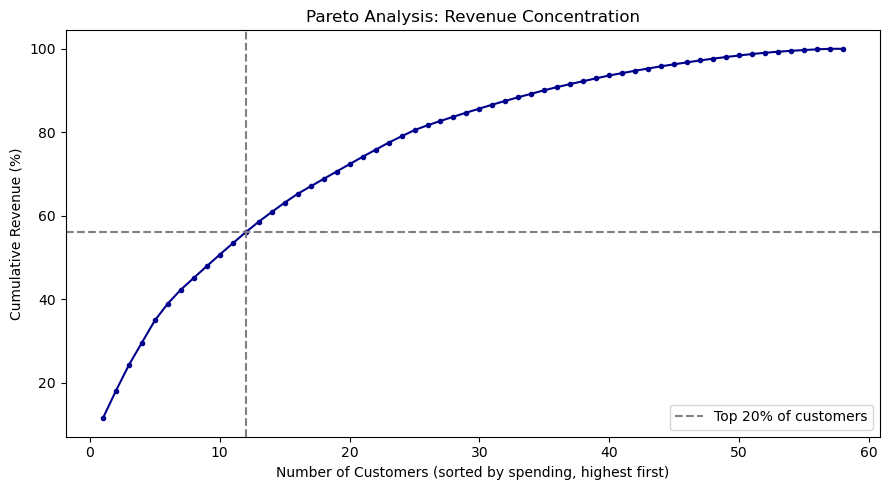

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(sorted_customers) + 1), sorted_customers["cumulative_pct"], marker="o", markersize=3, color="darkblue")
ax.axvline(top20_count, color="gray", linestyle="--", label="Top 20% of customers")
ax.axhline(top20_revenue_share, color="gray", linestyle="--")
ax.set_xlabel("Number of Customers (sorted by spending, highest first)")
ax.set_ylabel("Cumulative Revenue (%)")
ax.set_title("Pareto Analysis: Revenue Concentration")
ax.legend()
plt.tight_layout()

plt.show()

**Result and interpretation:**

**The top 20% of customers (12 out of 58) generate about 56% of total revenue.**

This isn't exactly the classic 80/20 pattern (which would mean 20% generating 80% of revenue), but the concentration is still significant: over half the store's revenue depends on one-fifth of its customers. (Note: if we exclude the customer with the suspicious data point, `customer_id = 1030`, this figure drops to about 50% — still a high concentration, just slightly less extreme.)

**Risk of this concentration for the company:**
- **Revenue dependency:** if even a few of these top 12 customers churn (and we already know from Question 4 that some of them are in the At Risk group), the revenue drop would be significant and immediate.
- **Customer bargaining power:** high-value customers may expect discounts or special treatment; losing them is costly.
- **Concentrated risk instead of stable growth:** the store's growth is overly dependent on keeping a small group happy, rather than having a broader base of solid mid-tier customers.


##   The CEO's Report (Top 3 Charts)


### Chart 1 — Total Revenue by City (from Question 2)
- **What it shows:** Revenue for each city, ranked.
- **Why it matters to the CEO:** Directly answers "which city should we advertise in?"
- **Decision it supports:** Allocate the advertising budget to Mashhad.

### Chart 2 — Customer Count by Segment (from Question 6)
- **What it shows:** How customers are distributed across the 4 segments (Champions / Loyal / At Risk / Needs Attention).
- **Why it matters to the CEO:** Gives a fast, high-level read on the overall health of the customer base — shows what proportion of customers are at risk.
- **Decision it supports:** Prioritize retention budget for the At Risk group instead of spending everything on acquiring new customers.

### Chart 3 — Pareto Analysis: Revenue Concentration (from Question 7)
- **What it shows:** How dependent revenue is on a small number of high-value customers.
- **Why it matters to the CEO:** Surfaces a strategic risk that isn't visible just by looking at total revenue.
- **Decision it supports:** Design a dedicated loyalty program for the top 10–12 customers (ties to Question 3) to manage this risk.

##  Three Data-Driven Recommendations

### Recommendation 1 — Win-back campaign for high-value inactive customers
**Evidence:** 18 customers (31% of the base) had above-median spending but haven't purchased in over 6 months (Question 4); this group also has below-average satisfaction.
**Action:** Design a personalized email/SMS campaign with a limited-time discount code, plus a short survey to understand why they stopped buying.
**KPI:** Percentage of this group that makes at least one new purchase within 30 days of the campaign (target: at least 15% of these 18 customers return).

### Recommendation 2 — Focus advertising budget on Mashhad
**Evidence:** Mashhad has the highest revenue (64,118), the highest average spending per customer (5,829), and the lowest return rate (11.7% vs an average of ~29% across other cities) (Question 2).
**Action:** Concentrate next quarter's entire advertising budget on Mashhad, with messaging built around that city's best-selling products.
**KPI:** Number of new customers acquired from Mashhad, and the return rate of those new customers (should stay close to the city's current rate, i.e. under 15%).

### Recommendation 3 — Investigate and reduce the return rate
**Evidence:** The store-wide return rate is 24.9% (Question 1), a high number, and in some cities (e.g. Ahvaz at 35%) it's even worse (Question 2). This lines up with the low overall satisfaction score (2.97 out of 5).
**Action:** Investigate which products or categories drive the most returns (requires a product category column that isn't currently in the dataset — see Question 10), and improve product descriptions/images or the sizing/exchange policy.
**KPI:** Reduce the store-wide return rate from 24.9% to under 15% within two quarters.

## Dataset Limitations

### Limitations

1. **No product-level information:** the dataset only has `avg_order_value` and `total_spending`, but doesn't specify *which* products a customer bought. Without a product category, we can't tell which products drive the high return rate or which categories sell best.

2. **No acquisition source:** we don't know how each customer found the store (social media, ads, word of mouth, etc.). Without this column, we can't determine which marketing channel is actually effective, or the customer acquisition cost (CAC) per channel.

3. **Small sample size:** the dataset only has 58 customers, and once split across cities or segments, some groups become very small (e.g. Isfahan has only 4 customers, and the Champions segment has only 2). This means city-level and segment-level conclusions can be heavily influenced by the behavior of just one or two individual customers, rather than reflecting a statistically reliable pattern.